### General Imports:


In [1]:
import os
import gymnasium as gym
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
from netsim.gym_basic.envs import MASKING_RMSA_ENV
from netsim.netSimPy import *
import numpy as np
import logging
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

logging.getLogger("tensorflow").setLevel(logging.FATAL)

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# FILES AND DIRECTORIES:
__file__ = "LR_RMSA.ipynb"
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split(".")[0]
log_dir = f"./tmp/{file_name}/"
# SIMULATION PARAMS:
EPISODE_LENGTH = 1000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 30000  # 300 Erlangs

networkPaths = "/Users/jbcedeno/Documents/projcts/multiband-gymnasium/networks/nsfnet"
network = Network(
    networkFileName=networkPaths + "/network.json",
    pathsFileName=networkPaths + "/routes.json",
    bitrateFilename=networkPaths + "/bitrates_c_bands.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
sim_args = dict(eventsGenerator=generator, network=network)
simulator = NetworkSimulator(**sim_args)
# Building the environment:
env_args = dict(
    simulator=simulator,
    episode_length=EPISODE_LENGTH,
    j=N_BLOCKS,
    n_paths=N_PATHS,
)

env: MASKING_RMSA_ENV = Monitor(gym.make("MASKING_RMSA_ENV-v0", **env_args), log_dir)
eval_env: MASKING_RMSA_ENV = Monitor(
    gym.make("MASKING_RMSA_ENV-v0", **env_args), log_dir + "eval_env"
)


best_model_dir = f"./tmp/ACTION_RMSA_ENV/best_smooth_model"
expert = MaskablePPO.load(best_model_dir)

### Masking import!!!


In [3]:
from netsim.explainable.common.masking import (
    predict_with_valid_classes,
    compute_mask,
    used_classes,
    # find_nth_one_position,
)
from sb3_contrib.common.maskable.utils import get_action_masks

masking = compute_mask(env)

In [4]:
def generate_trajectories(n_timesteps, model, env, only_accepted=True):
    trajectories = []
    timesteps_count = 0
    state = None
    done = False
    observation = env.reset()[0]
    actions = [0] * 15
    while timesteps_count < n_timesteps:
        action_masks = get_action_masks(env)
        act, state = model.predict(
            observation,  # type: ignore[arg-type]
            state=state,
            episode_start=done,
            deterministic=True,
            action_masks=action_masks,
        )
        # act, state = model.predict(
        #     observation,
        #     state=state,
        #     episode_start=done,
        #     deterministic=True,
        # )
        traj = {"obs": observation, "action": act}
        observation, reward, done, truncated, info = env.step(act)
        traj["reward"] = reward
        if only_accepted:
            if reward > 0:
                trajectories.append(traj)
                timesteps_count += 1
                actions[traj["action"]] += 1
        else:
            trajectories.append(traj)
            timesteps_count += 1
        if done:
            env.reset()
    return trajectories


def flatten_trajectories(traj):
    obs = [t["obs"] for t in traj]
    acts = [t["action"] for t in traj]
    rewards = [t["reward"] for t in traj]
    return obs, acts, rewards


class MixerPolicy:
    def __init__(self, expert, student, beta):
        self.student = student
        self.expert = expert
        self.beta = beta

    def set(self, expert, student, beta):
        self.student = student
        self.expert = expert
        self.beta = beta

    def predict(self, observation, state, episode_start, deterministic, action_masks):
        model = np.random.choice(["A", "B"], p=[self.beta, 1 - self.beta])
        if model == "A":
            return self.expert.predict(
                observation, state, episode_start, deterministic, action_masks
            )
        else:
            actions = predict_with_valid_classes(self.student, [observation], masking)
            return actions[0], None
            # return self.student.predict([observation])[0], None


def get_expert_acts(expert, obs, env):
    acts = []
    state = None
    done = False
    env.reset()
    action_masks = get_action_masks(env)
    for o in obs:
        act, state = expert.predict(
            o,
            state=state,
            episode_start=done,
            deterministic=True,
            action_masks=action_masks,
        )
        acts.append(act)
    return acts


def linear_beta(start, end, steps):
    def call(n):
        return max(start + n * (end - start) / (steps - 1), end)

    return call

In [7]:
from sklearn import ensemble
from sklearn.linear_model import RidgeClassifier
from IPython.display import clear_output
import pickle as pkl
import pandas as pd
import json


def decode_action(act, j):
    idx_path = act // j
    idx_block = act % j
    return idx_path, idx_block


def get_route_from_action(acts, j):
    return [decode_action(a, j)[0] for a in acts]


def evaluate_student(student, n_timesteps):
    env.reset(options={"hard_reset": True})
    traj = generate_trajectories(n_timesteps, expert, env)
    x_test = [t["obs"] for t in traj]
    y_test = [t["action"] for t in traj]
    # y_test =  get_route_from_action(y_test, env.j)
    y_pred = predict_with_valid_classes(student, x_test, masking)
    # y_pred = student.predict(x_test)

    # TODO: Update y_pred based on used_classes:
    # print(y_test)
    # print(used_classes)
    # print(y_pred)

    # y_pred = [find_nth_one_position(used_classes, y) for y in y_pred]
    # print("2", y_pred)

    # y_test2 = [0] * 15
    # for i in y_test:
    #     y_test2[i] += 1

    conf_matrix = confusion_matrix(y_test, y_pred)
    score = accuracy_score(y_test, y_pred)
    print(score, conf_matrix)


def train_with_dagger(
    expert,
    env,
    beta_func,
    n_rounds,
    timesteps_by_round,
    on_round_change=None,
    trajes_output_name=file_name + "_trajs.csv",
):
    student_policy = RidgeClassifier(positive=True)
    print(f"Starting round 1")
    print(f"Sampling new trajectories for round: {1} ")
    obs, acts, _rewards = flatten_trajectories(
        generate_trajectories(timesteps_by_round, expert, env)
    )

    # routes = get_route_from_action(acts, env.j)
    student_policy.fit(obs, acts)
    classes = used_classes(acts)
    evaluate_student(student_policy, 100000)

    for r in range(1, n_rounds):
        print(f"Starting round {r+1}")
        mixer = MixerPolicy(expert, student_policy, beta=beta_func(r))
        print(f"Sampling new trajectories for round: {r+1} ")
        obs2, _acts, _rewards = flatten_trajectories(
            generate_trajectories(timesteps_by_round, mixer, env)
        )
        acts2 = get_expert_acts(expert, obs2, env)

        # extend and update:
        shuffle = np.arange(len(obs2))
        np.random.shuffle(shuffle)
        obs2 = [obs2[s] for s in shuffle]
        acts2 = [acts2[s] for s in shuffle]
        obs.extend(obs2)
        acts.extend(acts2)

        # print(f"Saving trajectories for round: {r+1} ")
        # df = pd.DataFrame({'x':[json.dumps(o.tolist(),separators=(',', ':')) for o in obs2], 'y':acts2})
        # df.to_csv(trajes_output_name,
        #             mode="a",
        #             index=False,
        #             header=False
        #         )
        print(f"Fitting student for round: {r+1} ")
        # clear_output(wait=True)
        student_policy.fit(obs, acts)
        # classes = used_classes(acts)
        evaluate_student(student_policy, 100000)

    return student_policy

In [8]:
n_steps = 8
beta_func = linear_beta(1, 0, n_steps)
student = train_with_dagger(expert, env, beta_func, n_steps, timesteps_by_round=300000)

Starting round 1
Sampling new trajectories for round: 1 
0.66202 [[ 4057   168     0     0     0   302 14515     0     0     0]
 [  120 28926     0     0     0     1  2842     0     0     0]
 [   58     1     0     0     0     0    19     0     0     0]
 [    0     0     0   460     0     0     0     3     0     0]
 [    0     0     0   100    19     0     0    56     0     0]
 [ 1236   100     0     4     2  3230  9332    10     1     1]
 [  712  3526     0     1     0   305 27830     2     0     0]
 [    0     1     0    27     0     0     1   878     3     0]
 [   61     0     0    13     0     0     0    87   398     1]
 [  116    44     0     3     0    10    14     0     0   404]]
Starting round 2
Sampling new trajectories for round: 2 
Fitting student for round: 2 
0.55558 [[16483  1575     0     0     0   977     7     0     0     0]
 [  563 31318     0     0     0     8     0     0     0     0]
 [   77     1     0     0     0     0     0     0     0     0]
 [    0     0     0 

### Saving the agent


In [9]:
pickle_out = open("student_LR.pkl", "wb")
pkl.dump(student, pickle_out)
pickle_out.close()
# pickle_out = open("student_LR.pkl","rb")
# student = pkl.load(pickle_out)
# pickle_out.close()

In [10]:
def get_actions_count(y_test):
    y1_test = [0] * 15
    for yv in y_test:
        y1_test[yv] += 1
    return y1_test

### Global accuracy


In [11]:
def get_metrics(matrix):
    # Calcula métricas
    precision = np.diag(matrix) / np.sum(matrix, axis=0)
    recall = np.diag(matrix) / np.sum(matrix, axis=1)
    specificity = np.diag(matrix) / (np.sum(matrix, axis=1) - np.diag(matrix))
    f1_score = 2 * (precision * recall) / (precision + recall)

    # Imprime las métricas
    for i in range(len(precision)):
        print(f"Clase {i + 1}:")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  F1-score: {f1_score[i]:.4f}")
        print(f"  Sensibilidad (Recall): {recall[i]:.4f}")
        print(f"  Especificidad: {specificity[i]:.4f}\n")

In [15]:
traj = generate_trajectories(200000, expert, env)
x_test = [t["obs"] for t in traj]
y_test = [int(t["action"]) for t in traj]

y_pred = predict_with_valid_classes(student, x_test, masking)
# y_pred = student.predict(x_test)
score = accuracy_score(y_test, y_pred)
print(score)
print(f1_score(y_test, y_pred, average="weighted"))
conf_matrix = confusion_matrix(y_test, y_pred, labels=[i for i in range(15)])
print(conf_matrix)

0.638195
0.5914300961583223
[[ 6579   279     0     0     0     0     0   103     0 31094     0     0
      0     0     0]
 [   53 58846     0     0     0     0     0     1     0  4171     0     0
      0     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [    2     4     0     0     0     0     0     0     0   175     0     0
      0     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [    0     0     0     0     0   912     3     0     0     0     4     0
      0     0     0]
 [    0     0     0     0     0   189    32     0     0     0    79     0
      0     0     0]
 [  149   318     0     0     0     8     0  5236     0 22421     5     0
      0     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [    2 11054     0     0     0     1     0   910     0 53064     0     0
      1     0     0]
 [    1     0     0   

In [16]:
get_metrics(conf_matrix)

Clase 1:
  Precision: 0.9116
  F1-score: 0.2906
  Sensibilidad (Recall): 0.1729
  Especificidad: 0.2090

Clase 2:
  Precision: 0.8339
  F1-score: 0.8807
  Sensibilidad (Recall): 0.9330
  Especificidad: 13.9280

Clase 3:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 4:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000

Clase 5:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 6:
  Precision: 0.7267
  F1-score: 0.8390
  Sensibilidad (Recall): 0.9924
  Especificidad: 130.2857

Clase 7:
  Precision: 0.9143
  F1-score: 0.1910
  Sensibilidad (Recall): 0.1067
  Especificidad: 0.1194

Clase 8:
  Precision: 0.8301
  F1-score: 0.3040
  Sensibilidad (Recall): 0.1861
  Especificidad: 0.2286

Clase 9:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 10:
  Precision: 0.4782
  F1-score: 0.6030
  Sensibilidad (Recall): 0.8160
  Especificid

/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_5835/453134526.py:3: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(matrix) / np.sum(matrix, axis=0)
/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_5835/453134526.py:4: RuntimeWarning: invalid value encountered in divide
  recall = np.diag(matrix) / np.sum(matrix, axis=1)
/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_5835/453134526.py:5: RuntimeWarning: invalid value encountered in divide
  specificity = np.diag(matrix) / (np.sum(matrix, axis=1) - np.diag(matrix))


### Inter-path accuracy


In [17]:
n_conf_matrix = np.zeros(shape=(3, 3))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n_conf_matrix[ir // 5, ic // 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n_conf_matrix)
print(s[0])
print(n_conf_matrix)

0.76052
[[65763. 35544.     0.]
 [11523. 82776.    89.]
 [  502.   238.  3565.]]


In [18]:
# Matriz de confusión proporcionada
confusion_matrix = np.array(n_conf_matrix)

get_metrics(confusion_matrix)

Clase 1:
  Precision: 0.8454
  F1-score: 0.7344
  Sensibilidad (Recall): 0.6491
  Especificidad: 1.8502

Clase 2:
  Precision: 0.6982
  F1-score: 0.7774
  Sensibilidad (Recall): 0.8770
  Especificidad: 7.1285

Clase 3:
  Precision: 0.9756
  F1-score: 0.8958
  Sensibilidad (Recall): 0.8281
  Especificidad: 4.8176



### Inter-spectrum accuracy


In [19]:
n2_conf_matrix = np.zeros(shape=(5, 5))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n2_conf_matrix[ir % 5, ic % 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n2_conf_matrix)
print(s[0])
print(n2_conf_matrix)

0.63878
[[9.3470e+03 2.8800e+02 1.0300e+02 0.0000e+00 3.1099e+04]
 [1.0860e+03 5.9212e+04 1.6000e+01 0.0000e+00 4.1720e+03]
 [4.9300e+02 3.8800e+02 6.1330e+03 0.0000e+00 2.2450e+04]
 [2.0000e+00 4.0000e+00 0.0000e+00 0.0000e+00 1.7500e+02]
 [3.0000e+00 1.1054e+04 9.1100e+02 0.0000e+00 5.3064e+04]]


In [20]:
# Matriz de confusión proporcionada
confusion_matrix = np.array(n2_conf_matrix)

get_metrics(confusion_matrix)

Clase 1:
  Precision: 0.8551
  F1-score: 0.3611
  Sensibilidad (Recall): 0.2289
  Especificidad: 0.2968

Clase 2:
  Precision: 0.8346
  F1-score: 0.8744
  Sensibilidad (Recall): 0.9182
  Especificidad: 11.2272

Clase 3:
  Precision: 0.8562
  F1-score: 0.3349
  Sensibilidad (Recall): 0.2082
  Especificidad: 0.2629

Clase 4:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000

Clase 5:
  Precision: 0.4782
  F1-score: 0.6030
  Sensibilidad (Recall): 0.8160
  Especificidad: 4.4338



/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_5835/453134526.py:3: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(matrix) / np.sum(matrix, axis=0)


In [21]:
def evaluate_bp_student(student, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.reset(options={"lambda": mLambda})
    observation = env.reset()[0]
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        # act = predict([observation], student, env)[0]
        act = predict_with_valid_classes(student, [observation], masking)[0]
        # act = student.predict([observation])[0]
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps


def evaluate_expert(expert, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.reset(options={"lambda": mLambda})
    observation = env.reset()
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        act, state = expert.predict(
            observation,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps

In [ ]:
loads = [10000, 12500, 15000, 17500, 20000, 22500, 25000]
N_EVALUATIONS = 2000000
lr_bp = []

for l in loads:
    bp = round(evaluate_bp_student(student, N_EVALUATIONS, l), 7)
    print(bp)
    lr_bp.append(bp)
print(lr_bp)

[0.000145, 0.00016, 0.0002695, 0.0006865, 0.0016225, 0.0037385, 0.006849]


### features importance


[6.09289815e-07 5.75520829e-08 7.03987519e-07 3.39537875e-07
 2.61150717e-07 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 7.60630980e-08
 8.61210081e-08 1.49612336e-07 0.00000000e+00 2.09614071e-09
 3.86982122e-07 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.00291557e-07 1.84276876e-07 0.00000000e+00 3.94718431e-07
 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.98801549e-07
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 5.30932114e-04
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.89177385e-06 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 4.948622

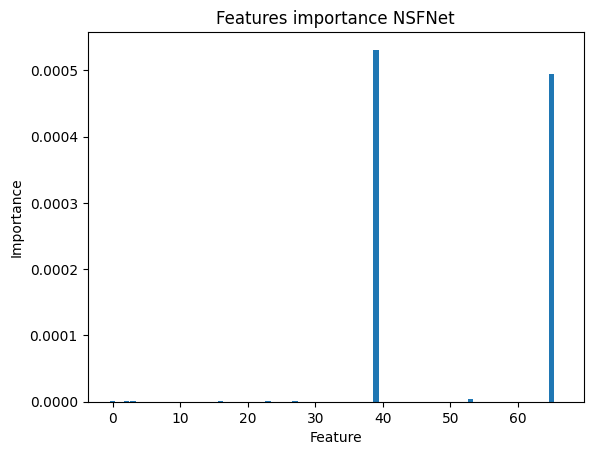

In [32]:
import pandas as pd

base_output_dir_features = f"./plots/{__file__}/features_importance_heuristic/"

output_dir = base_output_dir_features
os.makedirs(output_dir, exist_ok=True)

for i, importances_sk in enumerate(student.coef_):
    # importances_sk = student.coef_[i]
    importance = pd.DataFrame(importances_sk)
    importance.to_csv(f"{output_dir}features_importance_{i}.csv")


importances_sk = student.coef_[5]
importance = pd.DataFrame(importances_sk)
importance.to_csv(f"{output_dir}features_importance_heuristic.csv")
print(importances_sk)
plt.figure()
plt.bar([x for x in range(len(importances_sk))], importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Features importance NSFNet")
plt.savefig(output_dir + "NSFNet.png")
plt.show()